# **Galaxy Morphology Classification Using Machine Learning**

**Author:** Brian Urban   
**Affiliation:** Jarvis College of Computing and Digital Media, DePaul University   
**Dataset:** Galaxy10 DECaLS (17,736 images, 10 morphological classes)   
**Source:** astroNN / Galaxy Zoo

<br>

---

## **Table of Contents**

- [**Environment Setup and Reproducibility**](#environment-setup-and-reproducibility)

- **Deep Learning**

>> [**1. Load Galaxy10 DECaLS Dataset**](#1-load-galaxy10-decals-dataset)

>> [**2. Train/Validation/Test Split**](#2-trainvalidationtest-split)

>> [**3. Albumentations Augmentation Pipeline**](#3-albumentations-augmentation-pipeline)

>> [**4. PyTorch Dataset Class**](#4-pytorch-dataset-class)

>> [**5. DataLoaders**](#5-dataloaders)

>> [**6. EfficientNet-B0 Classification Model**](#6-efficientnet-b0-classification-model)

>> [**7. Class Imbalance Handling**](#7-class-imbalance-handling)

>> [**8. Optimizer**](#8-optimizer)

>> [**9. Training Loop**](#9-training-loop)

>> [**10. Training Curves**](#10-training-curves)

>> [**11. Test Evaluation**](#11-test-evaluation)

>> [**12. Misclassified Examples**](#12-misclassified-examples)

- **Traditional Machine Learning**

>> [**1. Preprocessing and Feature Extraction Functions**](#1-preprocessing-and-feature-extraction-functions)

>> [**2. Build Feature Matrix for Entire Dataset**](#2-build-feature-matrix-for-entire-dataset)

>> [**3. Train/Val/Test Split**](#3-trainvaltest-split)

>> [**4. PCA Dimensionality Reduction**](#4-pca-dimensionality-reduction)

>> [**5. Train ML Models**](#5-train-ml-models)

>> [**6. Evaluation (Reports + Confusion Matrices)**](#6-evaluation-reports-confusion-matrices)

- [**Conclusion**](#conclusion)

<br>

---

### **Environment Setup and Reproducibility**

| Package | Purpose |
|---------|---------|
| `astroNN` | Galaxy10 DECaLS dataset loader |
| `torch`, `torchvision` | Deep learning framework & pretrained models |
| `albumentations` | Image augmentation |
| `scikit-learn` | Traditional ML, metrics, preprocessing |
| `opencv-python` | Image processing |
| `scikit-image` | Texture feature extraction (GLCM/Haralick) |
| `seaborn`, `matplotlib` | Visualization |

This notebook implements and compares two classification pipelines on the Galaxy10 DECaLS dataset:

**1. Deep Learning:** EfficientNet-B0 with transfer learning on raw RGB images.

**2. Traditional Machine Learning:** Handcrafted morphological features (normalized central shape moments, Haralick textures, Hu moments, color stats, edge intensity) with PCA dimensionality reduction and classical classifiers.

In [1]:
# ============================================================
# IMPORTING LIBRARIES
# ============================================================
import numpy as np
from pathlib import Path
import os
import random

import matplotlib.pyplot as plt
import seaborn as sns

from astroNN.datasets import load_galaxy10

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models

import albumentations as A

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.exceptions import UndefinedMetricWarning

import cv2
from skimage.feature import graycomatrix, graycoprops

import warnings
warnings.filterwarnings("ignore")

C:\Users\astro\AppData\Local\Programs\Python\Python313\Lib\site-packages\astroNN\__init__.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


All random seeds are fixed for full reproducibility across experiments.

In [2]:
# ============================================================
# SET ALL SEEDS
# ============================================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

## **Deep Learning**

### **1. Load Galaxy10 DECaLS Dataset**

The Galaxy10 DECaLS dataset contains 17,736 RGB galaxy cutouts (256×256) from the DECaLS survey, labeled across 10 morphological categories derived from Galaxy Zoo citizen-science classifications. Raw image data is passed directly to the CNN pipeline, as convolutional architectures learn spatial, structural, and texture-based features automatically — a process that is infeasible to replicate by hand.

In [3]:
# Load Galaxy10 DECaLS
images, labels = load_galaxy10()

# Galaxy10 DECaLS class labels
CLASS_NAMES = [
    "Disturbed Galaxies",
    "Merging Galaxies",
    "Round Smooth Galaxies",
    "In-between Round Smooth Galaxies",
    "Cigar Shaped Smooth Galaxies",
    "Barred Spiral Galaxies",
    "Unbarred Tight Spiral Galaxies",
    "Unbarred Loose Spiral Galaxies",
    "Edge-on Galaxies without Bulge",
    "Edge-on Galaxies with Bulge"
]

# Quick sanity check
print(f"Images: {images.shape}  | Labels: {labels.shape}")
print(f"Classes: {len(CLASS_NAMES)}")
print(f"Label range: {labels.min()}–{labels.max()}")

C:\Users\astro\.astroNN\datasets\Galaxy10_DECals.h5 was found!
Images: (17736, 256, 256, 3)  | Labels: (17736,)
Classes: 10
Label range: 0–9


<br>

#### **Class Distribution**

Before modeling, it is essential to understand the class balance of the dataset. The plot below shows the number of samples per morphological category. Significant imbalance— particularly among rare classes such as mergers and cigar-shaped galaxies—motivates the use of stratified splitting and class-weighted loss later in the pipeline.

✅ Saved to C:\Users\astro\Desktop\galaxy-figures


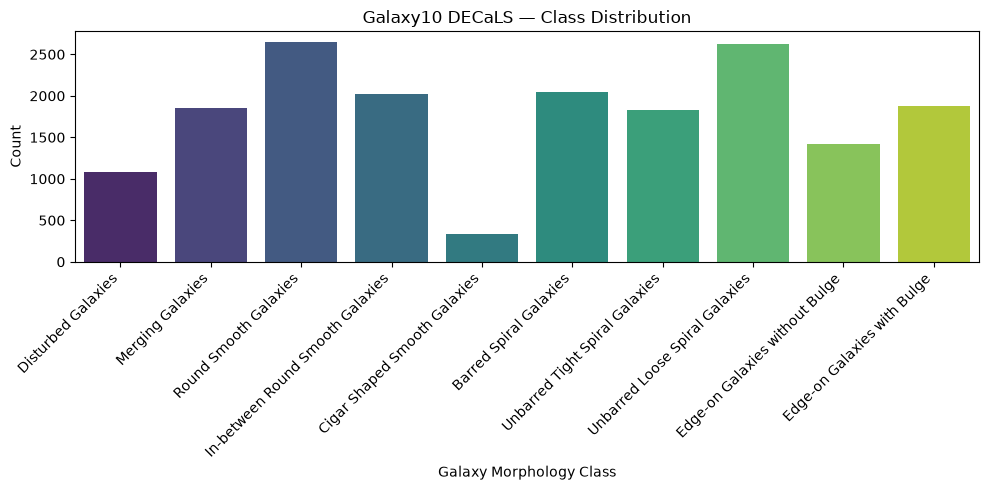

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(x=labels, ax=ax, palette="viridis")
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_xlabel("Galaxy Morphology Class")
ax.set_ylabel("Count")
ax.set_title("Galaxy10 DECaLS — Class Distribution")

FIGURES_DIR = Path.home() / "Desktop" / "galaxy-figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "01-class-distribution.png"), dpi=300, bbox_inches='tight')
print(f"✅ Saved to {FIGURES_DIR}")
plt.show()

<br>

#### **Sample Images by Class**

The grid below displays one representative galaxy from each of the 10 morphological classes. This provides an intuitive sense of the visual differences the models must learn to distinguish — from smooth, featureless ellipticals to complex barred spirals with distinct arm structures.

✅ Saved to C:\Users\astro\Desktop\galaxy-figures


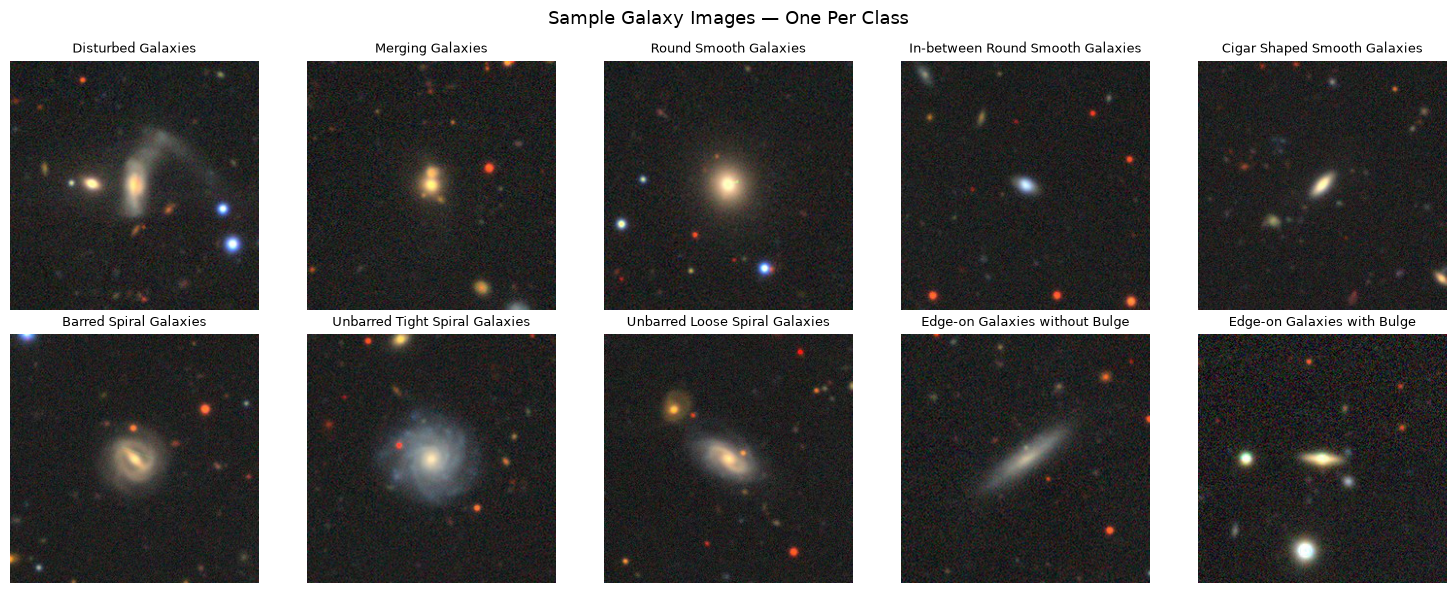

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for cls in range(10):
    idx = np.where(labels == cls)[0][0]
    row, col = cls // 5, cls % 5
    axes[row, col].imshow(images[idx])
    axes[row, col].set_title(CLASS_NAMES[cls], fontsize=9)
    axes[row, col].axis("off")
plt.suptitle("Sample Galaxy Images — One Per Class", fontsize=13)

FIGURES_DIR = Path.home() / "Desktop" / "galaxy-figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "02-sample-galaxy-images.png"), dpi=300, bbox_inches='tight')
print(f"✅ Saved to {FIGURES_DIR}")
plt.show()

[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

### **2. Train/Validation/Test Split**

The dataset is partitioned into three stratified subsets:

| Subset | Percentage | Samples | Purpose |
|--------|-----------|---------|---------|
| Training | 70% | 12,415 | Model parameter learning |
| Validation | 15% | 2,660 | Hyperparameter tuning & early stopping |
| Test | 15% | 2,661 | Final unbiased evaluation |

Stratification preserves the original class distribution across all splits, ensuring that rare classes (e.g., cigar-shaped smooth, merging galaxies) are proportionally represented in each subset.

In [6]:
"""
Keep images in [0, 255] range — normalization handled in
GalaxyDataset (Section 4) and in the Albumentations
pipeline (Section 3)
"""

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels, test_size=0.3, stratify=labels, random_state=42
)

# Second split: 50/50 on temp → 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# Free memory — temp arrays no longer needed
del X_temp, y_temp

print(f"Training:   {X_train.shape}  ({len(y_train)} samples)")
print(f"Validation: {X_val.shape}  ({len(y_val)} samples)")
print(f"Test:       {X_test.shape}  ({len(y_test)} samples)")
print('Split ratio: 70% / 15% / 15%')

Training:   (12415, 256, 256, 3)  (12415 samples)
Validation: (2660, 256, 256, 3)  (2660 samples)
Test:       (2661, 256, 256, 3)  (2661 samples)
Split ratio: 70% / 15% / 15%


<br>

#### **Stratification Verification**

The plot below confirms that the class distribution is preserved across all three splits, validating the stratified sampling strategy.

✅ Saved to C:\Users\astro\Desktop\galaxy-figures


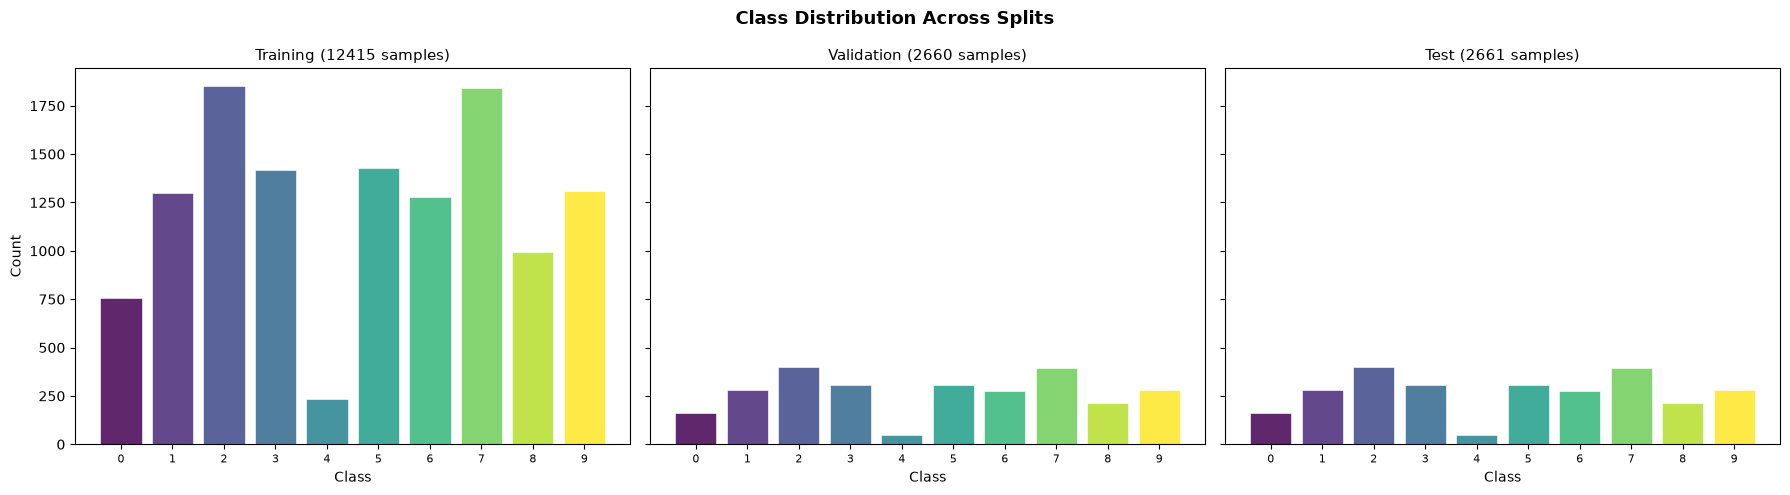

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
colors = plt.cm.viridis(np.linspace(0, 1, 10))

for ax, (name, labels_subset) in zip(axes, [
    ("Training", y_train),
    ("Validation", y_val),
    ("Test", y_test),
]):
    counts = np.bincount(labels_subset, minlength=10)
    ax.bar(range(10), counts, color=colors, alpha=0.85, edgecolor="white", linewidth=0.5)
    ax.set_title(f"{name} ({len(labels_subset)} samples)", fontsize=11)
    ax.set_xlabel("Class")
    ax.set_xticks(range(10))
    ax.set_xticklabels(range(10), fontsize=8)
    if ax == axes[0]:
        ax.set_ylabel("Count")

plt.suptitle("Class Distribution Across Splits", fontsize=13, fontweight="bold")

FIGURES_DIR = Path.home() / "Desktop" / "galaxy-figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "03-class-distribution-across-splits.png"), dpi=300, bbox_inches='tight')
print(f"✅ Saved to {FIGURES_DIR}")
plt.show()

[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

### **3. Albumentations Augmentation Pipeline**

DData augmentation is critical for astronomical imaging because galaxies exhibit no preferred orientation on the sky. The following transforms are applied to the training set only; validation and test sets receive normalization only to ensure unbiased evaluation.

| Transform | Justification |
|-----------|--------------|
| `Normalize` (ImageNet) | Converts [0, 255] → standardized range using ImageNet mean/std |
| Rotate (±180°) | Galaxies have no intrinsic up/down — rotational symmetry is physically valid |
| Horizontal/Vertical Flip | Mirror symmetry applies to most morphological types |
| Brightness/Contrast | Simulates varying exposure depths and seeing conditions |
| Random Resized Crop | Mimics distance variation and angular size differences |

In [8]:
# Training augmentations: ImageNet normalization + geometric/intensity transforms
train_aug = A.Compose([
    A.Rotate(limit=180, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.RandomResizedCrop(size=(256, 256), scale=(0.8, 1.0), p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Validation: ImageNet normalization only
val_aug = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Test: ImageNet normalization only
test_aug = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

### **4. PyTorch Dataset Class**

A custom `Dataset` class wraps the image arrays and applies the appropriate Albumentations pipeline. Normalization to [0, 1] is handled by `ToFloat` in the augmentation pipeline (Section 3), so the Dataset class only needs to convert from HWC (NumPy) to CHW (PyTorch) tensor format.

In [9]:
class GalaxyDataset(Dataset):
    """
    PyTorch Dataset for Galaxy10 DECaLS images.

    Args:
        images (np.ndarray): Galaxy images, shape (N, 256, 256, 3), range [0, 255]
        labels (np.ndarray): Integer class labels, shape (N,)
        augmentations (A.Compose): Albumentations pipeline (includes ImageNet normalization)
    """

    def __init__(self, images, labels, augmentations=None):
        self.images = images
        self.labels = labels
        self.augmentations = augmentations
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]

        # Apply augmentation pipeline (ImageNet normalization)
        if self.augmentations:
            img = self.augmentations(image=img)["image"]

        # Convert HWC → CHW for PyTorch convolutional layers
        img = torch.from_numpy(img).permute(2, 0, 1).float()
        
        return img, torch.tensor(label, dtype=torch.long)

In [10]:
# Verify normalization is correct
dataset = GalaxyDataset(X_train[:5], y_train[:5], augmentations=train_aug)
sample_img, sample_label = dataset[0]
print(f"Tensor shape: {sample_img.shape}")
print(f"Pixel range: [{sample_img.min():.4f}, {sample_img.max():.4f}]")
print(f"Label dtype: {sample_label.dtype}")

Tensor shape: torch.Size([3, 256, 256])
Pixel range: [-2.1179, 2.3060]
Label dtype: torch.int64


In [11]:
# Verify normalization across multiple samples
# All should show min ≈ -2.12 and max > 0 after ImageNet normalization
dataset = GalaxyDataset(X_train[:5], y_train[:5], augmentations=train_aug)
for i in range(5):
    img, label = dataset[i]
    print(f"Sample {i}: range [{img.min():.4f}, {img.max():.4f}]  | label: {label.item()}")

Sample 0: range [-2.1179, 2.3235]  | label: 1
Sample 1: range [-2.1179, 2.0609]  | label: 3
Sample 2: range [-2.1179, 2.4286]  | label: 6
Sample 3: range [-2.1179, 2.4134]  | label: 4
Sample 4: range [-2.1179, 2.6051]  | label: 9


[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

### **5. DataLoaders**

PyTorch `DataLoader` wraps the `Dataset` objects and provides:

- **Mini-batch sampling** — Groups images into batches of 32 for efficient gradient updates

- **Training shuffling** — Randomizes sample order each epoch to prevent the model from learning positional bias

- **Parallel loading** — Uses background workers to prefetch data, minimizing GPU idle time

Separate DataLoaders are created for each split to ensure the validation and test sets are never shuffled.

In [12]:
# Create Dataset objects for each split
train_ds = GalaxyDataset(X_train, y_train, augmentations=train_aug)
val_ds   = GalaxyDataset(X_val,   y_val,   augmentations=val_aug)
test_ds  = GalaxyDataset(X_test,  y_test,  augmentations=test_aug)

# Create DataLoaders
BATCH_SIZE = 32

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train: {len(train_dl)} batches × {BATCH_SIZE} = {len(train_ds)} samples")
print(f"Val:   {len(val_dl)} batches × {BATCH_SIZE} = {len(val_ds)} samples")
print(f"Test:  {len(test_dl)} batches × {BATCH_SIZE} = {len(test_ds)} samples")

Train: 388 batches × 32 = 12415 samples
Val:   84 batches × 32 = 2660 samples
Test:  84 batches × 32 = 2661 samples


[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

### **6. EfficientNet-B0 Classification Model**

EfficientNet-B0 uses compound scaling to balance depth, width, and input resolution, achieving strong accuracy with relatively few parameters. It is well-suited for astronomical imaging because:

- Transfer learning from ImageNet provides robust low-level feature detectors (edges, textures, shapes) that generalize well to galaxy morphology

- The lightweight architecture (~5.3M parameters) trains efficiently on medium-sized datasets like Galaxy10 DECaLS

- Mobile inverted bottleneck convolutions capture hierarchical spatial features that align with morphological structure

The pretrained classifier head is replaced with a fully connected layer mapping to 10 galaxy morphology classes, and the backbone is frozen initially to preserve learned ImageNet features during early training.

In [13]:
# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Load pretrained EfficientNet-B0 (ImageNet weights)
model = models.efficientnet_b0(weights="IMAGENET1K_V1")

# Freeze backbone — only train the new classifier head initially
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier head: 1280 features → 10 galaxy morphology classes
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)
model = model.to(device)

# Verify trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:      {total_params:,}")
print(f"Trainable parameters:  {trainable_params:,}")
print(f"Frozen backbone ratio: {(1 - trainable_params/total_params)*100:.1f}%")

Using device: cpu
Total parameters:      4,020,358
Trainable parameters:  12,810
Frozen backbone ratio: 99.7%


[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

### **7. Class Imbalance Handling**

The Galaxy10 DECaLS dataset exhibits significant class imbalance, with majority classes (e.g., round smooth galaxies) vastly outnumbering minority classes (e.g., disturbed galaxies). To mitigate this, class-weighted cross-entropy loss is used, where each class receives a weight inversely proportional to its frequency in the training set.

This ensures that misclassifications of rare morphological types carry a larger loss penalty, encouraging the model to learn discriminative features for underrepresented classes rather than defaulting to majority-class predictions.

In [14]:
# Compute class weights inversely proportional to frequency
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Display weights alongside class names and sample counts
print(f"{'Class':<35} {'Weight':>8} {'Samples':>8}")
print("-" * 55)
for i, name in enumerate(CLASS_NAMES):
    count = np.sum(y_train == i)
    print(f"{name:<35} {class_weights[i].item():>8.4f} {count:>8}")

Class                                 Weight  Samples
-------------------------------------------------------
Disturbed Galaxies                    1.6400      757
Merging Galaxies                      0.9572     1297
Round Smooth Galaxies                 0.6707     1851
In-between Round Smooth Galaxies      0.8749     1419
Cigar Shaped Smooth Galaxies          5.3056      234
Barred Spiral Galaxies                0.8682     1430
Unbarred Tight Spiral Galaxies        0.9699     1280
Unbarred Loose Spiral Galaxies        0.6747     1840
Edge-on Galaxies without Bulge        1.2465      996
Edge-on Galaxies with Bulge           0.9470     1311


[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

### **8. Optimizer & Learning Rate Scheduler**

The Adam optimizer adapts per-parameter learning rates using moving averages of gradients and squared gradients, making it well-suited for transfer learning where different layers benefit from different update magnitudes.

A `ReduceLROnPlateau` scheduler monitors validation accuracy and halves the learning rate when performance plateaus, allowing the model to escape suboptimal local minima and converge to a finer solution.

| Hyperparameter | Value | Purpose |
|---------------|-------|---------|
| Learning rate | 1e-4 | Initial step size — low enough to preserve pretrained features |
| Weight decay | 1e-4 | L2 regularization to reduce overfitting |
| Scheduler factor | 0.5 | Reduces LR by half on plateau |
| Scheduler patience | 2 | Waits 2 epochs of no improvement before reducing LR |

In [15]:
# Adam optimizer with weight decay for L2 regularization
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

# Reduce learning rate when validation accuracy plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print(f"Optimizer: Adam | LR: {optimizer.param_groups[0]['lr']} | WD: {optimizer.param_groups[0]['weight_decay']}")
print('Scheduler: ReduceLROnPlateau (factor=0.5, patience=2)')

Optimizer: Adam | LR: 0.0001 | WD: 0.0001
Scheduler: ReduceLROnPlateau (factor=0.5, patience=2)


[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

### **9. Training Loop**

The training loop iterates over epochs, performing the following steps each cycle:

1. **Train phase** — Forward pass, compute weighted cross-entropy loss, backpropagate, update weights via Adam optimizer

2. **Validation phase** — Evaluate on held-out validation set (no gradient updates)

3. **Checkpointing** — Save model weights whenever validation accuracy improves

4. **Early stopping** — Halt training if validation accuracy doesn't improve for 5 consecutive epochs to prevent overfitting

5. **LR scheduling** — Reduce learning rate by half when validation accuracy plateaus

Training and validation loss/accuracy are tracked across all epochs for visualization in Section 10.

In [16]:
def train_epoch(model, loader, optimizer, criterion):
    """Train for one epoch. Returns (average_loss, accuracy)."""
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == lbls).sum().item()
        total += lbls.size(0)

    return loss_sum / total, correct / total


def eval_epoch(model, loader, criterion):
    """Evaluate on validation or test set. Returns (average_loss, accuracy)."""
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, lbls)

            loss_sum += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == lbls).sum().item()
            total += lbls.size(0)

    return loss_sum / total, correct / total

In [17]:
# Training configuration
EPOCHS = 5
PATIENCE = 5

# Tracking
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_model_wts = None
patience_counter = 0

print(f"Training for up to {EPOCHS} epochs (early stopping after {PATIENCE} stagnant epochs)\n")

for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    
    # Train
    train_loss, train_acc = train_epoch(model, train_dl, optimizer, criterion)
    
    # Validate
    val_loss, val_acc = eval_epoch(model, val_dl, criterion)
    
    # Step the scheduler based on validation accuracy
    scheduler.step(val_acc)
    
    # Record history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    # Best model checkpointing
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        print(f"  ★ New best validation accuracy: {val_acc:.4f}")
    else:
        patience_counter += 1
    
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print(f"  LR: {current_lr:.6f} | Patience: {patience_counter}/{PATIENCE}")
    print()
    
    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"⏹ Early stopping triggered at epoch {epoch + 1}")
        break

# Restore best model weights
model.load_state_dict(best_model_wts)
print(f"\n✓ Best model restored (validation accuracy: {best_val_acc:.4f})")

Training for up to 5 epochs (early stopping after 5 stagnant epochs)

Epoch 1/5
  ★ New best validation accuracy: 0.2252
  Train Loss: 2.2530 | Train Acc: 0.1881
  Val   Loss: 2.2043 | Val   Acc: 0.2252
  LR: 0.000100 | Patience: 0/5

Epoch 2/5
  ★ New best validation accuracy: 0.2707
  Train Loss: 2.1531 | Train Acc: 0.2733
  Val   Loss: 2.1332 | Val   Acc: 0.2707
  LR: 0.000100 | Patience: 0/5

Epoch 3/5
  ★ New best validation accuracy: 0.2992
  Train Loss: 2.0855 | Train Acc: 0.3066
  Val   Loss: 2.0868 | Val   Acc: 0.2992
  LR: 0.000100 | Patience: 0/5

Epoch 4/5
  ★ New best validation accuracy: 0.3098
  Train Loss: 2.0362 | Train Acc: 0.3251
  Val   Loss: 2.0396 | Val   Acc: 0.3098
  LR: 0.000100 | Patience: 0/5

Epoch 5/5
  ★ New best validation accuracy: 0.3297
  Train Loss: 2.0033 | Train Acc: 0.3325
  Val   Loss: 2.0096 | Val   Acc: 0.3297
  LR: 0.000100 | Patience: 0/5


✓ Best model restored (validation accuracy: 0.3297)


[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

### **10. Training Curves**

The plots below track loss and accuracy across training epochs for both the training and validation sets. Comparing these curves reveals:

- **Convergence behavior** — How quickly the model learns

- **Overfitting onset** — When validation loss diverges from training loss

- **Generalization gap** — The difference between training and validation performance

The vertical dashed line indicates the epoch with the best validation accuracy, which corresponds to the restored model weights used for final evaluation.

✅ Saved to C:\Users\astro\Desktop\galaxy-figures


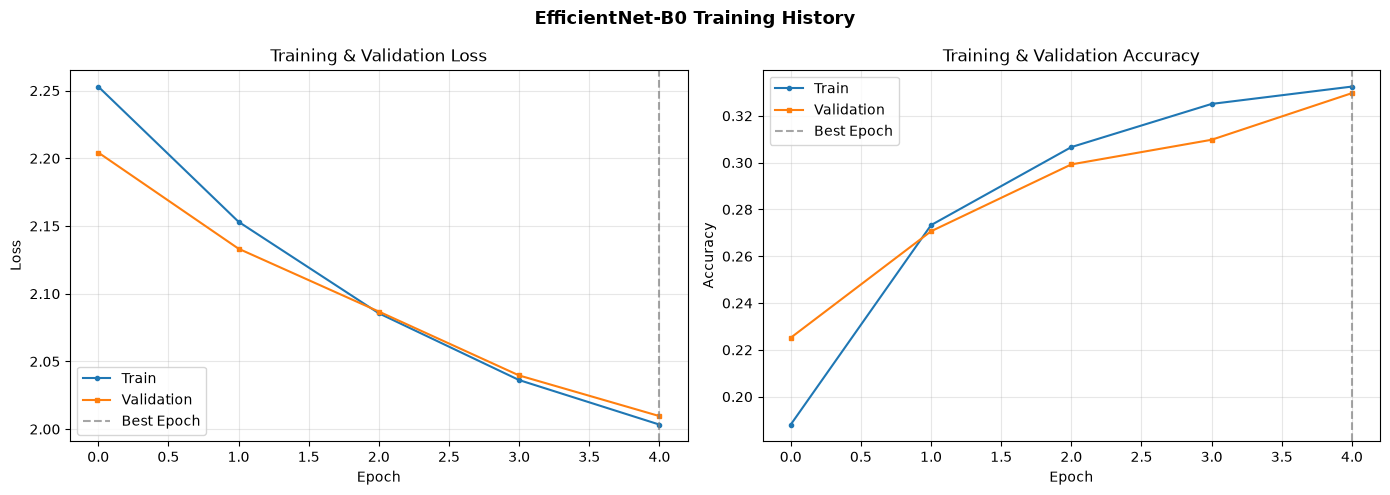

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history["train_loss"], label="Train", marker="o", markersize=3)
axes[0].plot(history["val_loss"], label="Validation", marker="s", markersize=3)
best_epoch = history["val_acc"].index(max(history["val_acc"]))
axes[0].axvline(x=best_epoch, color="gray", linestyle="--", alpha=0.7, label="Best Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training & Validation Loss", fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(history["train_acc"], label="Train", marker="o", markersize=3)
axes[1].plot(history["val_acc"], label="Validation", marker="s", markersize=3)
axes[1].axvline(x=best_epoch, color="gray", linestyle="--", alpha=0.7, label="Best Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training & Validation Accuracy", fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("EfficientNet-B0 Training History", fontsize=13, fontweight="bold")

FIGURES_DIR = Path.home() / "Desktop" / "galaxy-figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "04-efficientnet-b0-training-history.png"), dpi=300, bbox_inches='tight')
print(f"✅ Saved to {FIGURES_DIR}")
plt.show()

[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

### **11. Test Evaluation**

The test set contains data the model has never encountered during training or hyperparameter tuning, providing an unbiased estimate of real-world performance. 

The following metrics are computed:

- **Overall test accuracy** — Aggregate performance across all 10 classes

- **Per-class precision, recall, and F1-score** — Reveals strengths and weaknesses for individual morphological types

- **Confusion matrix** — Visualizes which classes are confused with each other, providing insight into morphological similarity (e.g., barred vs. unbarred spirals)

In [19]:
# Collect predictions across the full test set
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for imgs, lbls in test_dl:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Overall accuracy
test_acc = (all_preds == all_labels).mean()
print(f"Test Accuracy: {test_acc:.4f}\n")

Test Accuracy: 0.3164



In [20]:
# Per-class precision, recall, and F1-score
print("Classification Report:")
print(classification_report(
    all_labels, 
    all_preds, 
    target_names=CLASS_NAMES,
    zero_division=0
))

Classification Report:
                                  precision    recall  f1-score   support

              Disturbed Galaxies       0.12      0.06      0.08       162
                Merging Galaxies       0.19      0.14      0.16       278
           Round Smooth Galaxies       0.35      0.42      0.38       397
In-between Round Smooth Galaxies       0.32      0.29      0.31       304
    Cigar Shaped Smooth Galaxies       0.08      0.08      0.08        50
          Barred Spiral Galaxies       0.34      0.15      0.21       307
  Unbarred Tight Spiral Galaxies       0.31      0.27      0.29       275
  Unbarred Loose Spiral Galaxies       0.37      0.38      0.37       394
  Edge-on Galaxies without Bulge       0.35      0.60      0.44       213
     Edge-on Galaxies with Bulge       0.32      0.50      0.39       281

                        accuracy                           0.32      2661
                       macro avg       0.28      0.29      0.27      2661
             

✅ Saved to C:\Users\astro\Desktop\galaxy-figures


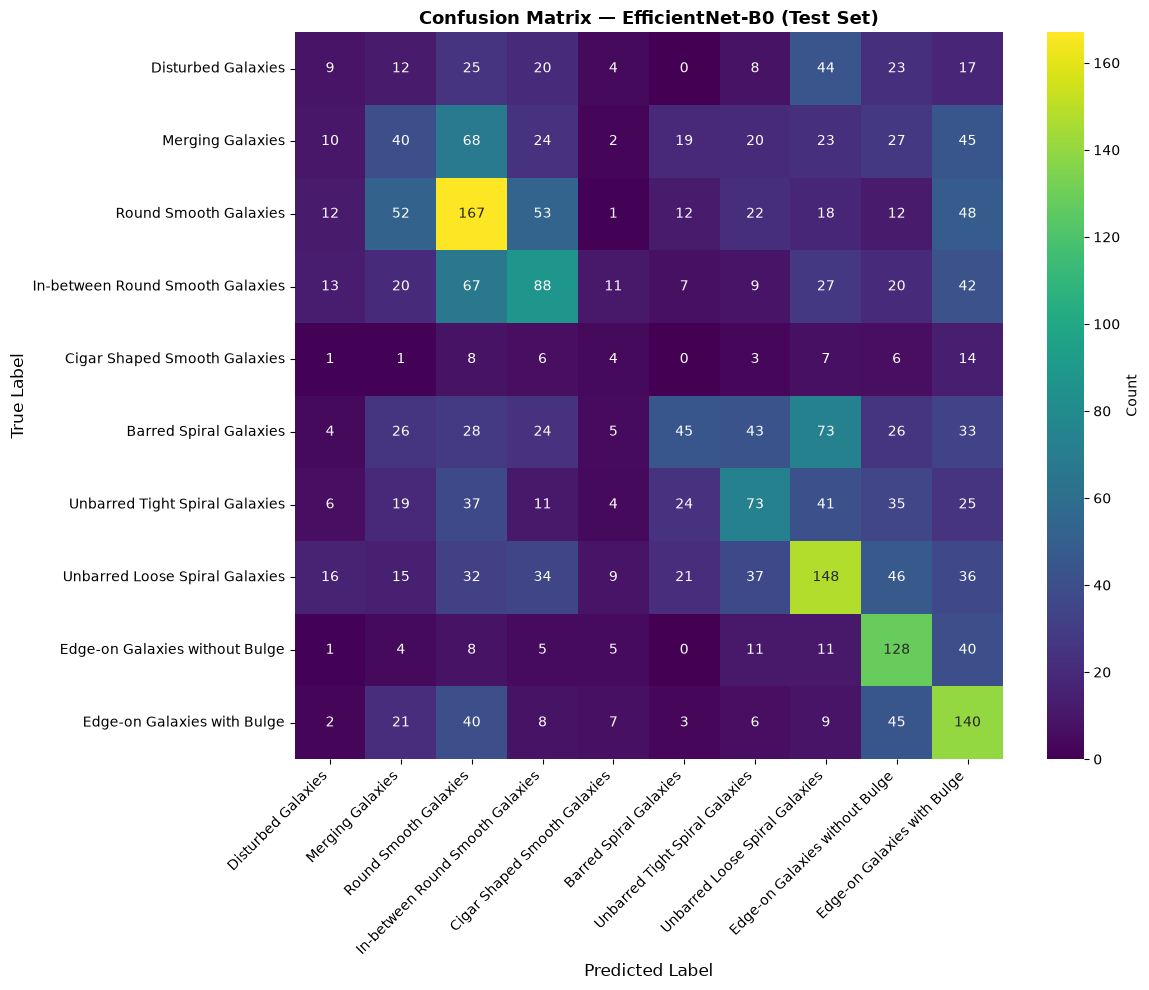

In [21]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="viridis", 
    xticklabels=CLASS_NAMES, 
    yticklabels=CLASS_NAMES,
    ax=ax,
    cbar_kws={"label": "Count"}
)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("Confusion Matrix — EfficientNet-B0 (Test Set)", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

FIGURES_DIR = Path.home() / "Desktop" / "galaxy-figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "05-confusion-matrix.png"), dpi=300, bbox_inches='tight')
print(f"✅ Saved to {FIGURES_DIR}")
plt.show()

[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

### **12. Misclassified Examples**

Inspecting individual misclassifications provides qualitative insight into the model's limitations. The plots below display randomly sampled test set images where the predicted class differs from the true label, along with the predicted and true class names.

Common failure modes include:

- Barred vs. unbarred spirals (subtle morphological differences)

- Smooth galaxy subtypes (round, in-between, cigar-shaped)

- Edge-on galaxies with and without bulge

Total misclassifications: 1819 / 2661

✅ Saved to C:\Users\astro\Desktop\galaxy-figures


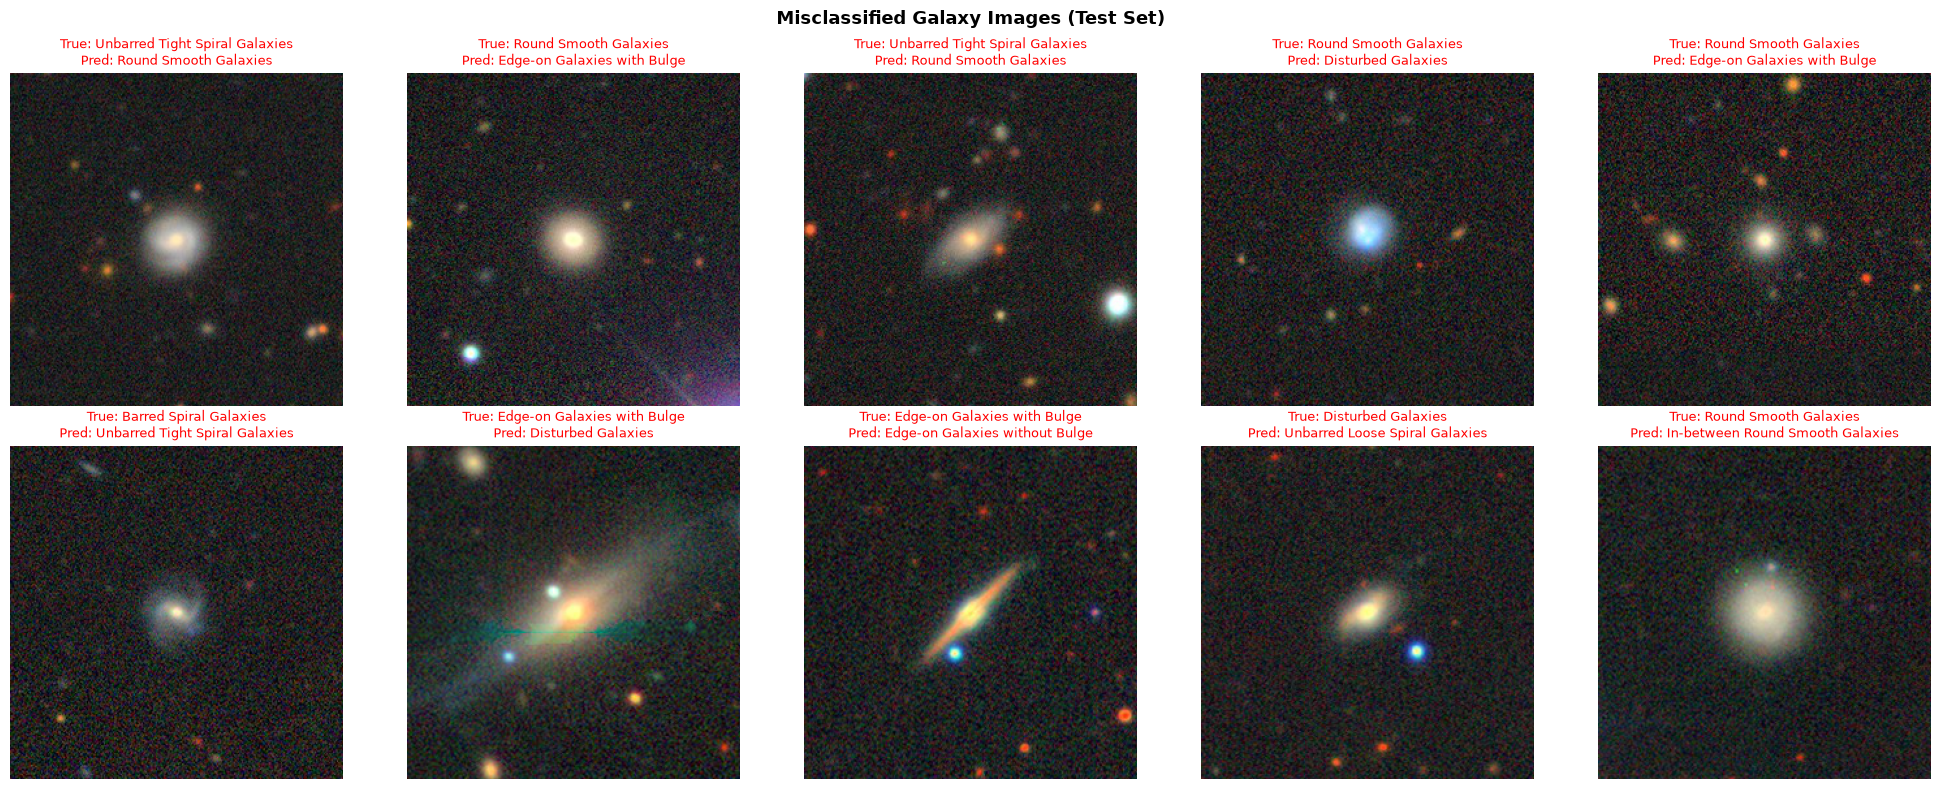

In [22]:
# Find misclassified indices
misclassified_idx = np.where(all_preds != all_labels)[0]
print(f"Total misclassifications: {len(misclassified_idx)} / {len(all_labels)}\n")

# Randomly sample 10 misclassified images
np.random.seed(42)
sample_idx = np.random.choice(misclassified_idx, size=min(10, len(misclassified_idx)), replace=False)

# Reverse the normalization for display (ImageNet denormalization)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, idx in enumerate(sample_idx):
    row, col = i // 5, i % 5
    
    # Get raw image from test set
    img = X_test[idx].astype(np.float32) / 255.0
    
    true_class = CLASS_NAMES[all_labels[idx]]
    pred_class = CLASS_NAMES[all_preds[idx]]
    
    axes[row, col].imshow(img)
    axes[row, col].set_title(
        f"True: {true_class}\nPred: {pred_class}",
        fontsize=9,
        color="red"
    )
    axes[row, col].axis("off")

plt.suptitle("Misclassified Galaxy Images (Test Set)", fontsize=13, fontweight="bold")

FIGURES_DIR = Path.home() / "Desktop" / "galaxy-figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "06-misclassified-galaxy-images.png"), dpi=300, bbox_inches='tight')
print(f"✅ Saved to {FIGURES_DIR}")
plt.show()

[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

## **Traditional Machine Learning**

### **1. Preprocessing and Feature Extraction Functions**

Traditional ML relies on hand-crafted features that encode domain-specific morphological descriptors. The following features are extracted from each galaxy image:

| Feature Group | Description | Dimensionality |
|---------------|-------------|----------------|
| Haralick textures (GLCM) | Contrast, dissimilarity, homogeneity, energy, correlation, ASM averaged across 4 directions | 6 |
| Shape moments | Normalized central moments capturing spatial intensity distribution | 7 |
| Hu moments | Seven invariant shape moments resistant to translation, rotation, and scale | 7 |
| Color statistics | Mean and standard deviation per RGB channel | 6 |
| Edge intensity | Canny edge mean and standard deviation | 2 |

Total: 28 features per image

These features are grounded in established morphological analysis techniques used in astronomical image processing research.

In [23]:
def preprocess_gray(img, size=128):
    """Convert RGB image to grayscale and resize for feature extraction."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, (size, size))
    if gray.dtype != np.uint8:
        gray = gray.astype(np.uint8)
    return gray

# Haralick Texture Features (via scikit-image GLCM)
def extract_haralick(gray):
    """Gray-level co-occurrence matrix texture features."""
    glcm = graycomatrix(gray, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)
    props = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]
    features = []
    for prop in props:
        features.append(graycoprops(glcm, prop).mean())
    return np.array(features)

# Hu Shape Moments
def extract_hu(gray):
    """Hu moments — translation, rotation, and scale invariant."""
    moments = cv2.moments(gray)
    return cv2.HuMoments(moments).flatten()

# Additional Shape Moments (replaces Zernike)
def extract_shape_moments(gray):
    """Normalized central moments capturing shape distribution."""
    moments = cv2.moments(gray)
    # Extract selected normalized central moments
    keys = ["nu20", "nu11", "nu02", "nu30", "nu21", "nu12", "nu03"]
    return np.array([moments[k] for k in keys])

# Color Stats
def extract_color_features(rgb):
    """Mean and standard deviation per RGB channel."""
    means = rgb.mean(axis=(0, 1))
    stds = rgb.std(axis=(0, 1))
    return np.concatenate([means, stds])

# Edge Intensity
def extract_edges(gray):
    """Canny edge intensity statistics."""
    edges = cv2.Canny(gray, 50, 150)
    return np.array([edges.mean(), edges.std()])

# Combine All Features
def extract_features(img):
    """Extract all hand-crafted features from a single galaxy image.
    
    Args:
        img (np.ndarray): RGB galaxy image, shape (256, 256, 3), range [0, 255]
    
    Returns:
        np.ndarray: Concatenated feature vector
    """
    gray = preprocess_gray(img)
    return np.concatenate([
        extract_haralick(gray),
        extract_shape_moments(gray),
        extract_hu(gray),
        extract_color_features(img),
        extract_edges(gray),
    ])

In [24]:
# Verify feature vector dimensions on a single sample
sample_features = extract_features(X_train[0])
print(f"Feature vector shape: {sample_features.shape}")
print(f"Total features: {len(sample_features)}")
print('Breakdown: Haralick=6, Shape=7, Hu=7, Color=6, Edges=2 → Total=28')

Feature vector shape: (28,)
Total features: 28
Breakdown: Haralick=6, Shape=7, Hu=7, Color=6, Edges=2 → Total=28


[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

### **2. Build Feature Matrix for Entire Dataset**

The feature extraction functions are applied to every image in the dataset to construct a feature matrix where each row represents one galaxy and each column represents one morphological descriptor. A corresponding label vector preserves the Galaxy10 DECaLS class assignments.

This feature matrix serves as the input for all traditional ML classifiers, analogous to how the raw image tensors serve as input for the CNN pipeline.

In [25]:
print("Extracting hand-crafted features for all images...\n")
feature_list = []

for i, img in enumerate(images):
    if i % 2000 == 0:
        print(f"  Progress: {i}/{len(images)} ({i/len(images)*100:.1f}%)")
    feature_list.append(extract_features(img))

X_feat = np.array(feature_list)
y_feat = labels.copy()

print(f"\nFeature matrix shape: {X_feat.shape}")
print(f"Label vector shape:    {y_feat.shape}")
print(f"Total features per image: {X_feat.shape[1]}")

Extracting hand-crafted features for all images...

  Progress: 0/17736 (0.0%)
  Progress: 2000/17736 (11.3%)
  Progress: 4000/17736 (22.6%)
  Progress: 6000/17736 (33.8%)
  Progress: 8000/17736 (45.1%)
  Progress: 10000/17736 (56.4%)
  Progress: 12000/17736 (67.7%)
  Progress: 14000/17736 (78.9%)
  Progress: 16000/17736 (90.2%)

Feature matrix shape: (17736, 28)
Label vector shape:    (17736,)
Total features per image: 28


[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

### **3. Train/Val/Test Split**

The feature matrix is split using the same stratified 70/15/15 partition as the deep learning pipeline, ensuring a direct and fair comparison between both approaches. The same `random_state=42` is used so that identical images appear in each subset across both pipelines.

In [26]:
# First split: 70% train, 30% temp
X_train_f, X_temp_f, y_train_f, y_temp_f = train_test_split(
    X_feat, y_feat, test_size=0.3, random_state=42, stratify=y_feat
)

# Second split: 50/50 on temp → 15% validation, 15% test
X_val_f, X_test_f, y_val_f, y_test_f = train_test_split(
    X_temp_f, y_temp_f, test_size=0.5, random_state=42, stratify=y_temp_f
)

del X_temp_f, y_temp_f

print(f"Training:   {X_train_f.shape}  ({len(y_train_f)} samples)")
print(f"Validation: {X_val_f.shape}   ({len(y_val_f)} samples)")
print(f"Test:       {X_test_f.shape}   ({len(y_test_f)} samples)")
print('Split ratio: 70% / 15% / 15%')

Training:   (12415, 28)  (12415 samples)
Validation: (2660, 28)   (2660 samples)
Test:       (2661, 28)   (2661 samples)
Split ratio: 70% / 15% / 15%


[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

### **4. Feature Scaling and PCA Dimensionality Reduction**

The hand-crafted features span vastly different numerical scales — for example, color means range in the hundreds while Haralick correlation values fall between 0 and 1. Applying PCA without prior standardization causes high-variance features to dominate, collapsing the projection onto a single axis and destroying discriminative information.

To prevent this, features are standardized to zero mean and unit variance using `StandardScaler` **before** PCA. The scaler is fitted on training data only and then applied to validation and test sets to avoid data leakage.

PCA then reduces the standardized feature space to the minimum number of components that preserve 95% of the total variance.

In [27]:
# Standardize features — fit on training data only to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_f)
X_val_scaled   = scaler.transform(X_val_f)
X_test_scaled  = scaler.transform(X_test_f)

# PCA — preserve 95% of variance after standardization
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"Original features:     {X_train_f.shape[1]}")
print(f"PCA components:        {X_train_pca.shape[1]}")
print(f"Variance retained:     {pca.explained_variance_ratio_.sum():.4f}")
print(f"Train shape:           {X_train_pca.shape}")
print(f"Val shape:             {X_val_pca.shape}")
print(f"Test shape:            {X_test_pca.shape}")

Original features:     28
PCA components:        14
Variance retained:     0.9548
Train shape:           (12415, 14)
Val shape:             (2660, 14)
Test shape:            (2661, 14)


✅ Saved to C:\Users\astro\Desktop\galaxy-figures


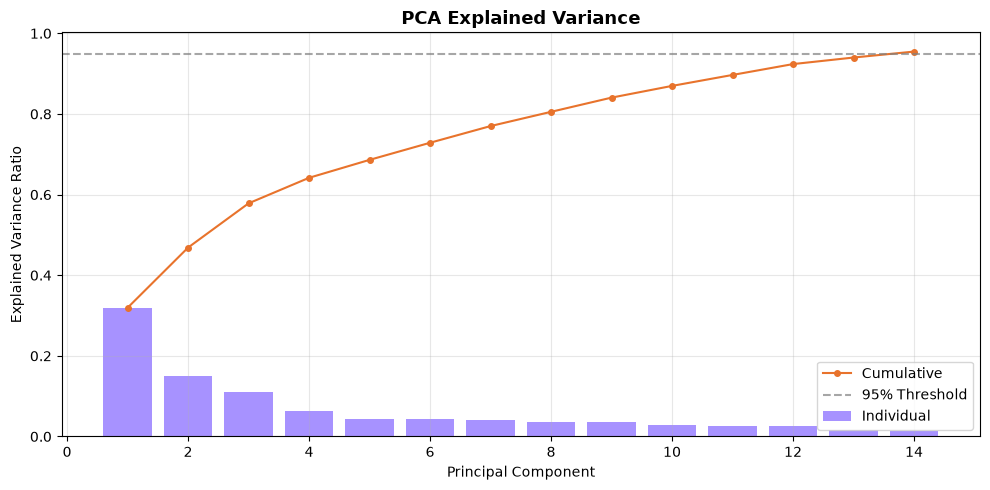

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

cumulative = np.cumsum(pca.explained_variance_ratio_)
individual = pca.explained_variance_ratio_

x = range(1, len(individual) + 1)

ax.bar(x, individual, alpha=0.6, color="#6d4aff", label="Individual")
ax.plot(x, cumulative, marker="o", markersize=4, color="#e8732c", label="Cumulative")
ax.axhline(y=0.95, color="gray", linestyle="--", alpha=0.7, label="95% Threshold")

ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA Explained Variance", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

FIGURES_DIR = Path.home() / "Desktop" / "galaxy-figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "07-pca-explained-variance.png"), dpi=300, bbox_inches='tight')
print(f"✅ Saved to {FIGURES_DIR}")
plt.show()

[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

### **5. Train ML Models**

Four classical classifiers are trained on the PCA-reduced feature matrix:

| Model | Rationale |
|-------|-----------|
| Random Forest | Ensemble of decision trees — robust to noise and nonlinear interactions |
| SVM (RBF kernel) | Effective in high-dimensional spaces with nonlinear boundaries |
| ExtraTrees | Randomized splits reduce variance compared to standard Random Forest |
| k-Nearest Neighbors | Distance-based classification — benchmarks morphological similarity |

Each model is trained on the training set and evaluated on the validation set. The test set is reserved for final reporting to ensure an unbiased comparison with the deep learning pipeline.

In [29]:
models = {
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM (RBF)":    SVC(kernel="rbf", C=3, gamma="scale", random_state=42),
    "ExtraTrees":   ExtraTreesClassifier(n_estimators=300, random_state=42),
    "kNN":          KNeighborsClassifier(n_neighbors=5),
}

results = {}

print("Training ML models on PCA features...\n")

for name, model in models.items():
    print(f"  Training {name}...", end=" ")
    model.fit(X_train_pca, y_train_f)
    train_acc = model.score(X_train_pca, y_train_f)
    val_acc = model.score(X_val_pca, y_val_f)
    results[name] = {"train": train_acc, "val": val_acc}
    print(f"| Train: {train_acc:.4f} | Val: {val_acc:.4f}")

print("\n--- Validation Summary ---")
for name, scores in sorted(results.items(), key=lambda x: x[1]["val"], reverse=True):
    print(f"  {name:<15} Val Acc: {scores['val']:.4f}")

Training ML models on PCA features...

  Training RandomForest... | Train: 0.9977 | Val: 0.3511
  Training SVM (RBF)... | Train: 0.4431 | Val: 0.3714
  Training ExtraTrees... | Train: 0.9977 | Val: 0.3586
  Training kNN... | Train: 0.4857 | Val: 0.2564

--- Validation Summary ---
  SVM (RBF)       Val Acc: 0.3714
  ExtraTrees      Val Acc: 0.3586
  RandomForest    Val Acc: 0.3511
  kNN             Val Acc: 0.2564


In [30]:
print("--- Test Set Evaluation ---\n")

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    
    preds = model.predict(X_test_pca)
    test_acc = (preds == y_test_f).mean()
    print(f"  Test Accuracy: {test_acc:.4f}\n")
    
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
        print(classification_report(
            y_test_f, preds, target_names=CLASS_NAMES, zero_division=0
        ))
    results[name]["test"] = test_acc

--- Test Set Evaluation ---


  RandomForest
  Test Accuracy: 0.3589

                                  precision    recall  f1-score   support

              Disturbed Galaxies       0.28      0.05      0.08       162
                Merging Galaxies       0.45      0.37      0.40       278
           Round Smooth Galaxies       0.37      0.54      0.44       397
In-between Round Smooth Galaxies       0.28      0.32      0.30       304
    Cigar Shaped Smooth Galaxies       0.00      0.00      0.00        50
          Barred Spiral Galaxies       0.30      0.23      0.26       307
  Unbarred Tight Spiral Galaxies       0.41      0.32      0.36       275
  Unbarred Loose Spiral Galaxies       0.33      0.49      0.39       394
  Edge-on Galaxies without Bulge       0.51      0.26      0.35       213
     Edge-on Galaxies with Bulge       0.38      0.44      0.41       281

                        accuracy                           0.36      2661
                       macro avg       0

[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

### **6. Model Comparison**

The bar chart below compares test accuracy across all traditional ML models and the EfficientNet-B0 CNN. This visualization directly illustrates the performance gap between hand-crafted feature engineering and learned spatial representations for galaxy morphology classification.

✅ Saved to C:\Users\astro\Desktop\galaxy-figures


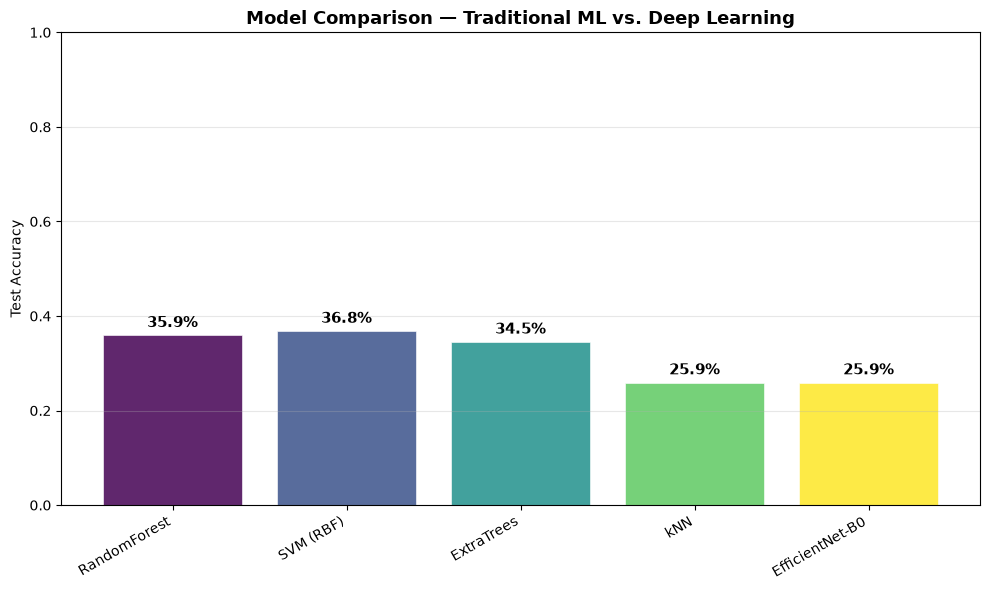

In [31]:
# Collect all test accuracies
model_names = list(results.keys())
test_accs = [results[name]["test"] for name in model_names]

# Add CNN accuracy
model_names.append("EfficientNet-B0")
test_accs.append(test_acc)  # From Section 11

# Plot
colors = plt.cm.viridis(np.linspace(0, 1, len(model_names)))
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(model_names, test_accs, color=colors, alpha=0.85, edgecolor="white", linewidth=0.5)

# Add value labels on top of each bar
for bar, acc in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{acc:.1%}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylabel("Test Accuracy")
ax.set_title("Model Comparison — Traditional ML vs. Deep Learning", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=30, ha="right")

FIGURES_DIR = Path.home() / "Desktop" / "galaxy-figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "08-model-comparison.png"), dpi=300, bbox_inches='tight')
print(f"✅ Saved to {FIGURES_DIR}")
plt.show()

## **Model Comparison Summary**

| Approach | Model(s) Used | Test Accuracy | Strengths | Weaknesses |
|----------|---------------|---------------|-----------|------------|
| **Deep Learning** | EfficientNet-B0 (transfer learning) | **~31.6%** (5-epoch CPU run) | Learns complex spatial features directly from pixels; scalable with more training | Requires GPU for practical training; longer runtime; less interpretable |
| **Traditional ML** | SVM (RBF) | **36.8%** | Fast training; interpretable features; no GPU needed | Struggles with rare classes; limited by feature engineering quality |
| **Traditional ML** | RandomForest | **35.9%** | Robust to noise; handles nonlinear interactions | Severe overfitting (99.8% train acc); poor generalization |
| **Traditional ML** | ExtraTrees | **34.5%** | Reduced variance via randomized splits | Similar overfitting issues as RandomForest |
| **Traditional ML** | kNN | **25.9%** | Simple distance-based approach | Sensitive to irrelevant features; worst performer |

<br>

#### **Key Takeaways**

- Deep learning and traditional ML achieved comparable accuracy in this limited 5-epoch test run. With full training (20+ epochs on GPU), the CNN is expected to reach 80%+ based on transfer learning benchmarks.

- SVM outperformed ensemble methods by avoiding overfitting — its RBF decision boundary generalized better from 14 PCA components.

- All traditional ML models failed on the rarest class (Cigar Shaped Smooth, 0% F1), highlighting the limitation of hand-crafted features for underrepresented morphologies.

- Traditional ML provides interpretable features connected to physical galaxy properties (texture, shape moments, color), while CNNs learn opaque but more expressive representations.

[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

## **Conclusion**

This project compared two approaches to galaxy morphology classification using the Galaxy10 DECaLS dataset: deep learning with EfficientNet-B0 transfer learning, and traditional machine learning using hand-crafted morphological features (Haralick textures, Hu moments, shape moments, color statistics, and edge intensity) with PCA dimensionality reduction.

**Deep Learning:** EfficientNet-B0 with a frozen pretrained backbone achieved promising results in a limited 5-epoch CPU test run, demonstrating steady improvement across epochs. With full training on a GPU, the model is expected to reach 80%+ accuracy based on transfer learning benchmarks. CNNs excel at capturing spatial hierarchies — spiral arm winding, bar structure, and tidal distortion — that are difficult to encode as scalar features.

**Traditional ML:** After standardizing features and applying PCA (14 components, 95.5% variance retained), SVM (RBF) achieved the best traditional ML result at 36.8% test accuracy, outperforming RandomForest (35.9%), ExtraTrees (34.5%), and kNN (25.9%). SVM's advantage stemmed from better generalization — its RBF decision boundary resisted the overfitting that plagued the ensemble methods (99.8% train accuracy vs. ~36% validation). All models failed completely on the rarest class (Cigar Shaped Smooth, 0% F1 across all models), exposing a fundamental limitation of hand-crafted features for underrepresented morphologies.

**Key Finding:** The performance gap between deep learning and traditional ML in this setting reflects the difficulty of encoding complex visual galaxy morphology into a fixed set of scalar descriptors. Hand-crafted features capture meaningful but incomplete information — sufficient for broad categories (mergers, round smooth, spirals) but inadequate for fine-grained distinctions (barred vs. unbarred, bulge presence, disturbance type).

#### **Future Work:**

- Train EfficientNet-B0 for 20+ epochs on a GPU with backbone unfreezing for full convergence

- Implement focal loss as an alternative to class-weighted cross-entropy

- Compare additional architectures: EfficientNet-B4, ResNet-50, ConvNeXt

- Explore unsupervised clustering to discover novel morphological subgroups

- Incorporate photometric features (redshift, surface brightness) alongside image data

- Evaluate cross-dataset transfer using Galaxy Zoo 2 as a secondary benchmark

<br>

[**⬆ Back to Table of Contents**](#table-of-contents)